## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    classification_report
)

In [3]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   


## Dataset Overview: Forest Fires (UCI ID 162)

- **517 rows**, 12 features in `X`, target `area` (hectares burned) in `y`
- **No missing values**: all columns fully populated
- **Feature types:** `month`, `day` are categorical (strings); `X`, `Y`, `RH` are ints; the remaining 7 columns are floats

### Feature Summary

| Column | Description | Distribution notes |
|---|---|---|
| `X` | Spatial grid coordinate (1–9) | Spread across the grid (quartiles 3, 4, 7) |
| `Y` | Spatial grid coordinate (2–9) | Concentrated around 4–5 (quartiles 4, 4, 5) |
| `month`, `day` | Categorical date fields | Need encoding |
| `FFMC` | Fine Fuel Moisture Code | Left-skewed: clusters near the top (median 91.6, 75th pct 92.9), long tail down to 18.7 |
| `DMC` | Duff Moisture Code | Right-skewed: 75th pct 142.4, max 291.3 |
| `DC` | Drought Code | Left-skewed: median 664.2 vs mean 547.9, 75th pct 713.9, max 860.6 |
| `ISI` | Initial Spread Index | Right-skewed: 75th pct 10.8, max 56.1 |
| `temp` | Temperature (°C) | Roughly symmetric, mean ~19°C |
| `RH` | Relative humidity (%) | Roughly symmetric, mean ~44% |
| `wind` | Wind speed (km/h) | Roughly symmetric, mean ~4 km/h |
| `rain` | Rainfall (mm) | Near-constant: 75th pct is 0.0, max 6.4, rain is rare |

### Target: `area`
- Heavily **zero-inflated and right-skewed**: 47.78% of observations are exactly `0.0` ha, with a long right tail (max 1090.84 ha)
- Modeling implications: consider `log(area + 1)`, or a two-stage approach (classify burn vs. no-burn, then regress on burned cases)

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.


--- Target (area) statistics ---
count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64
Proportion of zero-area observations: 47.78%


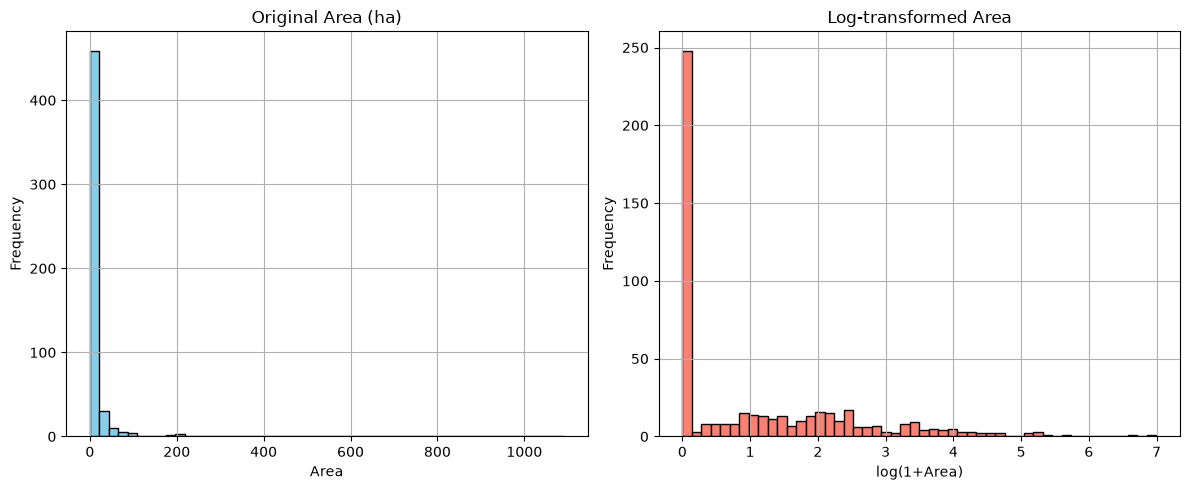

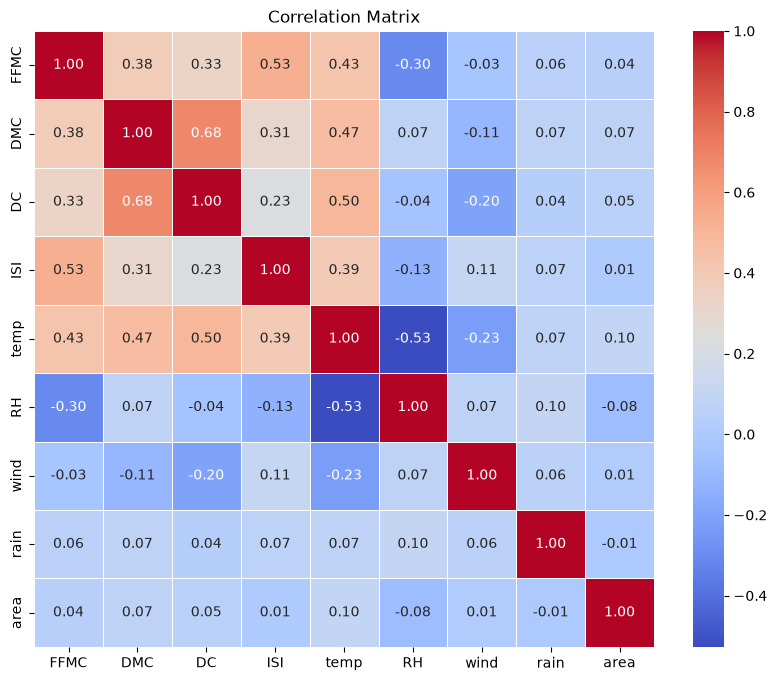

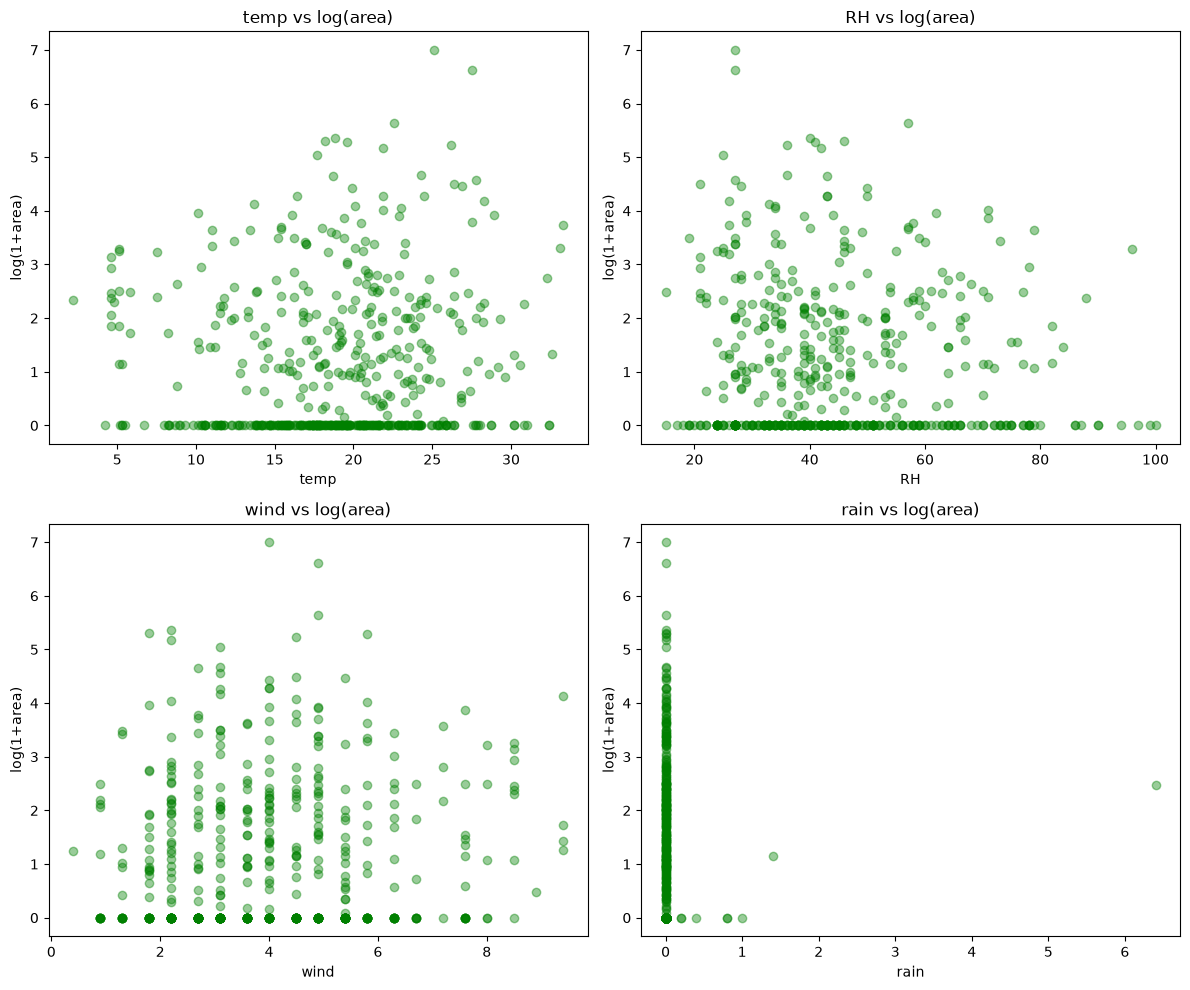


   EDA Insights:
   - Target 'area' is highly skewed (47.78% zeros, max 1090.84 ha) -> log transform helps.
   - Correlations with area are weak (all |r| <= 0.10; strongest is temp at 0.10).
   - Predictors are correlated with each other (e.g. DMC-DC r = 0.68), which may cause multicollinearity later.
   - No strong linear relationships -> consider nonlinear terms.
   


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine for analysis
data = X.copy()
data['area'] = y['area']

print("\n--- Target (area) statistics ---")
print(data['area'].describe())

zero_prop = (data['area'] == 0).mean() * 100
print(f"Proportion of zero-area observations: {zero_prop:.2f}%")

# Histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
data['area'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Original Area (ha)')
plt.xlabel('Area')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
np.log1p(data['area']).hist(bins=50, color='salmon', edgecolor='black')
plt.title('Log-transformed Area')
plt.xlabel('log(1+Area)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
# Correlation matrix
numeric_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
corr_matrix = data[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Scatterplots
data['log_area'] = np.log1p(data['area'])
key_predictors = ['temp', 'RH', 'wind', 'rain']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, pred in enumerate(key_predictors):
    ax = axes[i // 2, i % 2]
    ax.scatter(data[pred], data['log_area'], alpha=0.4, color='green')
    ax.set_xlabel(pred)
    ax.set_ylabel('log(1+area)')
    ax.set_title(f'{pred} vs log(area)')
plt.tight_layout()
plt.show()

print(f"""
   EDA Insights:
   - Target 'area' is highly skewed ({zero_prop:.2f}% zeros, max {data['area'].max():.2f} ha) -> log transform helps.
   - Correlations with area are weak (all |r| <= 0.10; strongest is temp at 0.10).
   - Predictors are correlated with each other (e.g. DMC-DC r = 0.68), which may cause multicollinearity later.
   - No strong linear relationships -> consider nonlinear terms.
   """)

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [5]:
# 3.1 Preprocess: one-hot encode month and day
X_encoded = pd.get_dummies(X, columns=['month', 'day'], drop_first=True)

# *** FIX: Convert all columns to float64 to avoid statsmodels dtype error ***
X_encoded = X_encoded.astype(float)

print("Shape after one-hot encoding:", X_encoded.shape)
print("\nData types after conversion:")
print(X_encoded.dtypes.value_counts())

# 3.2 Define target: log(area+1)
y_log = np.log1p(y['area'])

# 3.3 Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

# 3.4 Helper function to add quadratic terms
def add_quadratic_terms(df, vars_list):
    df_new = df.copy()
    for v in vars_list:
        df_new[f'{v}_sq'] = df_new[v] ** 2
    return df_new
# ----- Model 1: Baseline OLS -----
X_train_sm = sm.add_constant(X_train)   # add intercept
model_baseline = sm.OLS(y_train, X_train_sm).fit()
print("\n--- Baseline OLS Model ---")
print(model_baseline.summary())

# ----- Model 2: Add quadratic terms for temp, RH, wind, rain -----
X_quad = add_quadratic_terms(X_encoded, ['temp', 'RH', 'wind', 'rain'])
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_quad, y_log, test_size=0.2, random_state=42
)
model_quad = sm.OLS(y_train_q, sm.add_constant(X_train_q)).fit()
print("\n--- Model with Quadratic Terms ---")
print(model_quad.summary())

# ----- Model 3: Add interaction temp * RH -----
X_inter = X_quad.copy()
X_inter['temp_RH'] = X_inter['temp'] * X_inter['RH']
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_inter, y_log, test_size=0.2, random_state=42
)
model_inter = sm.OLS(y_train_i, sm.add_constant(X_train_i)).fit()
print("\n--- Model with Interaction Term ---")
print(model_inter.summary())

# ----- Model 4: Add log transformations for DC and rain -----
X_log = X_inter.copy()
X_log['log_DC'] = np.log1p(X_log['DC'])
X_log['log_rain'] = np.log1p(X_log['rain'])
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)
model_log = sm.OLS(y_train_l, sm.add_constant(X_train_l)).fit()
print("\n--- Model with Log Transforms ---")
print(model_log.summary())
# Keep the best model for diagnostics
best_ols_model = model_log


Shape after one-hot encoding: (517, 27)

Data types after conversion:
float64    27
Name: count, dtype: int64
Training set: 413 rows
Test set:     104 rows

--- Baseline OLS Model ---
                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.298
Date:                Thu, 01 Oct 2026   Prob (F-statistic):              0.149
Time:                        21:22:21   Log-Likelihood:                -699.45
No. Observations:                 413   AIC:                             1455.
Df Residuals:                     385   BIC:                             1568.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    s

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.


--- Model Comparison ---
         Model      R2  Adj_R2        AIC        BIC
0     Baseline  0.0834  0.0191  1454.8917  1567.5482
1    Quadratic  0.1028  0.0298  1454.0695  1582.8198
2  Interaction  0.1053  0.0300  1454.8956  1587.6694
3     LogTrans  0.1081  0.0279  1457.5964  1598.4170


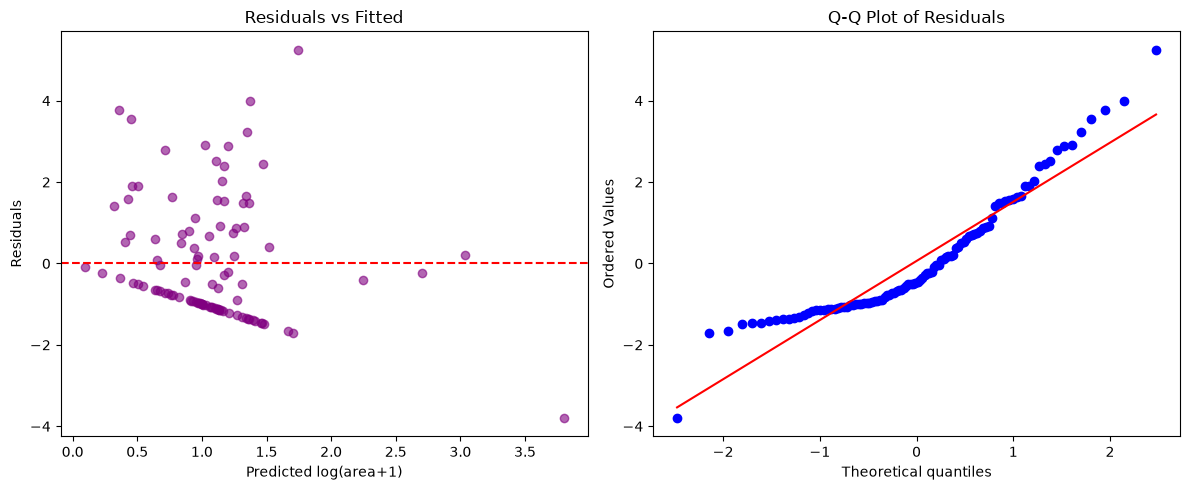

c:\Users\zaina\anaconda3\envs\data_analysis\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


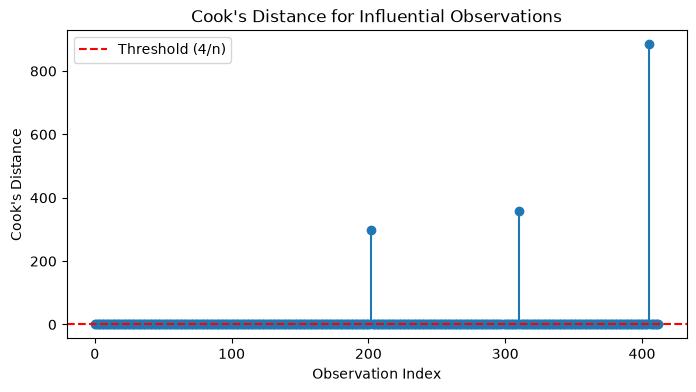

Number of influential observations: 23


In [6]:
# 4.1 Compare models using R², adjusted R², AIC, BIC
models = [model_baseline, model_quad, model_inter, model_log]
model_names = ['Baseline', 'Quadratic', 'Interaction', 'LogTrans']

metrics_df = pd.DataFrame({
    'Model': model_names,
    'R2': [m.rsquared for m in models],
    'Adj_R2': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models]
})
print("\n--- Model Comparison ---")
print(metrics_df.round(4))

# 4.2 Residual plots and Q-Q plot for the best model
X_test_l_sm = sm.add_constant(X_test_l)
y_pred = best_ols_model.predict(X_test_l_sm)
residuals = y_test_l - y_pred

plt.figure(figsize=(12, 5))

# Residuals vs fitted
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(area+1)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

# 4.3 Cook's Distance to identify influential observations
influence = OLSInfluence(best_ols_model)
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(8, 4))
plt.stem(range(len(cooks_d)), cooks_d, basefmt=" ")
plt.axhline(y=4/len(cooks_d), color='red', linestyle='--', label='Threshold (4/n)')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.title("Cook's Distance for Influential Observations")
plt.show()

influential_idx = np.where((cooks_d > 4/len(cooks_d)) | np.isnan(cooks_d))[0]
print(f"Number of influential observations: {len(influential_idx)}")



In [7]:
   # Test-set R² and MSE for each OLS model
test_sets = [
       ('Baseline',    model_baseline, X_test,   y_test),
       ('Quadratic',   model_quad,     X_test_q, y_test_q),
       ('Interaction', model_inter,    X_test_i, y_test_i),
       ('LogTrans',    model_log,      X_test_l, y_test_l),
   ]

rows = []
for name, m, Xt, yt in test_sets:
       pred = m.predict(sm.add_constant(Xt, has_constant='add'))
       rows.append({'Model': name,
                    'Test_R2': r2_score(yt, pred),
                    'Test_MSE': mean_squared_error(yt, pred)})

print(pd.DataFrame(rows).round(4))

         Model  Test_R2  Test_MSE
0     Baseline  -0.0472    2.3015
1    Quadratic  -0.0528    2.3140
2  Interaction  -0.0535    2.3155
3     LogTrans  -0.0271    2.2574


In [8]:

print("NaN values in Cook's D:", np.isnan(cooks_d).sum())

# Refit LogTrans model without the influential training rows
keep = np.setdiff1d(np.arange(len(X_train_l)), influential_idx)
m_clean = sm.OLS(y_train_l.iloc[keep],
                 sm.add_constant(X_train_l.iloc[keep])).fit()

pred_full  = model_log.predict(sm.add_constant(X_test_l, has_constant='add'))
pred_clean = m_clean.predict(sm.add_constant(X_test_l, has_constant='add'))

print(pd.DataFrame({
    'Model': ['With all rows', 'Without influential rows'],
    'n_train': [len(X_train_l), len(keep)],
    'Adj_R2': [model_log.rsquared_adj, m_clean.rsquared_adj],
    'Test_R2': [r2_score(y_test_l, pred_full), r2_score(y_test_l, pred_clean)],
    'Test_MSE': [mean_squared_error(y_test_l, pred_full),
                 mean_squared_error(y_test_l, pred_clean)],
}).round(4))

cols = ['temp', 'RH', 'DMC', 'log_DC']
print(pd.DataFrame({'All rows': model_log.params[cols],
                    'Without influential': m_clean.params[cols]}).round(4))

NaN values in Cook's D: 1
                      Model  n_train  Adj_R2  Test_R2  Test_MSE
0             With all rows      413  0.0279  -0.0271    2.2574
1  Without influential rows      390  0.0487  -0.0005    2.1990
        All rows  Without influential
temp     -0.2396              -0.1544
RH       -0.0042               0.0117
DMC       0.0054               0.0031
log_DC    0.2781               0.3032


### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [9]:
# 5.1 Scale predictors (necessary for Ridge/Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_l)
X_test_scaled = scaler.transform(X_test_l)

# 5.2 Ridge Regression with cross-validation
ridge = RidgeCV(alphas=np.logspace(-3, 5, 60), scoring='neg_mean_squared_error')
ridge.fit(X_train_scaled, y_train_l)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test_l, ridge_pred)
ridge_r2 = r2_score(y_test_l, ridge_pred)

# 5.3 Lasso Regression with cross-validation
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), random_state=42)
lasso.fit(X_train_scaled, y_train_l)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test_l, lasso_pred)
lasso_r2 = r2_score(y_test_l, lasso_pred)

print("\n--- Regularization Results ---")
print(f"Ridge  - MSE: {ridge_mse:.4f}, R²: {ridge_r2:.4f}")
print(f"Lasso  - MSE: {lasso_mse:.4f}, R²: {lasso_r2:.4f}")
# 5.4 Extract Lasso coefficients (feature selection)
lasso_coeff = pd.Series(lasso.coef_, index=X_train_l.columns)
non_zero = lasso_coeff[abs(lasso_coeff) > 1e-4].sort_values(ascending=False)
print("\nLasso non-zero coefficients (sorted):")
print(non_zero)


--- Regularization Results ---
Ridge  - MSE: 2.1835, R²: 0.0065
Lasso  - MSE: 2.1724, R²: 0.0116

Lasso non-zero coefficients (sorted):
month_dec    0.101526
DMC          0.054401
month_may    0.041113
month_sep    0.027252
X            0.021283
dtype: float64


In [10]:
print("Ridge alpha:", round(ridge.alpha_, 4))
print("Lasso alpha:", round(lasso.alpha_, 4))
print("Lasso kept", (abs(lasso.coef_) > 1e-4).sum(), "of", len(lasso.coef_), "features")

ridge_coeff = pd.Series(ridge.coef_, index=X_train_l.columns)
print("\nRidge: 8 largest coefficients by absolute value")
print(ridge_coeff.reindex(ridge_coeff.abs().sort_values(ascending=False).index).head(8).round(4))

Ridge alpha: 6020.8945
Lasso alpha: 0.091
Lasso kept 5 of 34 features

Ridge: 8 largest coefficients by absolute value
month_dec    0.0118
month_may    0.0083
DMC          0.0077
X            0.0069
month_sep    0.0068
month_mar   -0.0049
log_DC       0.0049
temp_sq      0.0048
dtype: float64


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [11]:
# 6.1 Create binary target: area > 0.5 ha (fire vs no significant fire)
threshold = 0.5
y_binary = (y['area'] > threshold).astype(int)
print("\n--- Binary target distribution ---")
print(y_binary.value_counts())

# 6.2 Select predictors (drop day dummies to reduce noise)
X_bin = X_encoded.drop(columns=[col for col in X_encoded.columns if 'day' in col])
print(f"Predictors for classification: {X_bin.shape[1]} features")

# 6.3 Stratified train/test split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 6.4 Scale predictors
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_bin.transform(X_test_bin)


--- Binary target distribution ---
area
1    260
0    257
Name: count, dtype: int64
Predictors for classification: 21 features


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [12]:
# 7.1 Train logistic regression with class balancing
logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg.fit(X_train_bin_scaled, y_train_bin)

# 7.2 Display coefficients and intercept
print("\n--- Logistic Regression Coefficients ---")
print(f"Intercept: {logreg.intercept_[0]:.4f}")
coeff_df = pd.DataFrame({
    'Feature': X_train_bin.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(coeff_df)

# 7.3 Predict probabilities and binary outcomes
y_prob = logreg.predict_proba(X_test_bin_scaled)[:, 1]
y_pred = logreg.predict(X_test_bin_scaled)

# 7.4 Evaluate performance
accuracy = accuracy_score(y_test_bin, y_pred)
conf = confusion_matrix(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
print("\n--- Classification Performance ---")
print(f"Accuracy : {accuracy:.4f}")
print("Confusion Matrix:\n", conf)
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_bin, y_pred))


--- Logistic Regression Coefficients ---
Intercept: 0.0218
      Feature  Coefficient
11  month_dec     0.618794
6        temp     0.206066
2        FFMC     0.192208
8        wind     0.131874
12  month_feb     0.087469
7          RH     0.080776
3         DMC     0.061717
1           Y     0.049269
4          DC     0.042831
0           X     0.035833
17  month_may     0.003524
18  month_nov     0.000000
5         ISI    -0.013807
14  month_jul    -0.013885
19  month_oct    -0.045592
20  month_sep    -0.066046
15  month_jun    -0.117171
9        rain    -0.128808
10  month_aug    -0.154758
16  month_mar    -0.179884
13  month_jan    -0.244757

--- Classification Performance ---
Accuracy : 0.5865
Confusion Matrix:
 [[29 23]
 [20 32]]
Precision: 0.5818
Recall   : 0.6154
F1-score : 0.5981

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.57        52
           1       0.58      0.62      0.60        52

   

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [13]:
   # Drop month_nov: constant in the training split (VIF is NaN)
keep_cols = [c for c in X_train_bin.columns if c != 'month_nov']
keep_idx = [list(X_train_bin.columns).index(c) for c in keep_cols]
X_vif = X_train_bin_scaled[:, keep_idx]

vif_data = pd.DataFrame({
       'Feature': keep_cols,
       'VIF': [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
   }).sort_values('VIF', ascending=False)

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data.round(2))
print("\nFeatures with VIF > 10:", vif_data.loc[vif_data['VIF'] > 10, 'Feature'].tolist())

--- Variance Inflation Factor (VIF) ---
      Feature    VIF
19  month_sep  44.78
10  month_aug  36.39
4          DC  25.36
14  month_jul   7.47
18  month_oct   6.13
16  month_mar   5.51
6        temp   4.39
3         DMC   3.97
15  month_jun   3.50
7          RH   2.73
11  month_dec   2.63
12  month_feb   2.52
2        FFMC   2.33
5         ISI   1.71
13  month_jan   1.64
0           X   1.64
1           Y   1.61
8        wind   1.27
17  month_may   1.26
9        rain   1.12

Features with VIF > 10: ['month_sep', 'month_aug', 'DC']


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

### Step 9: Summative Findings

**Regression.** I fit four OLS models on log(1+area): a baseline, then added quadratic terms (temp, RH, wind, rain), a temp×RH interaction, and log transforms of DC and rain. Training R² ranged from 0.083 to 0.108 and adjusted R² from 0.019 to 0.030, so the extra terms added almost nothing. The interaction model had the highest adjusted R² (0.030) and the baseline had the lowest BIC (1567.5). On the held-out test set all four had negative R² (-0.027 to -0.054), meaning they predicted slightly worse than the mean; the LogTrans model was the least bad (R² -0.027, MSE 2.257). Residuals were right-skewed with a floor created by the zero-area fires, and the Q-Q plot showed a heavy right tail, so a linear model does not suit this target.

**Influential points.** Cook's distance flagged 23 training observations (22 above 4/n plus one with an undefined value). Refitting without them raised adjusted R² from 0.028 to 0.049 and test R² from -0.027 to -0.0005, and changed some coefficients noticeably (temp from -0.240 to -0.154; RH from -0.004 to +0.012). The results are therefore sensitive to a few observations, although even the cleaned model has no real predictive power.

**Regularization.** Ridge (alpha 6020.9) and Lasso (alpha 0.091) gave test R² of 0.0065 and 0.0116 and MSE of 2.184 and 2.172. The difference between them is too small to call on 104 test rows. Both beat the full OLS (MSE 2.257) and slightly beat the cleaned OLS (MSE 2.199), but both are close to predicting the mean. Lasso kept 5 of 34 features: month_dec, DMC, month_may, month_sep and X, and Ridge's largest coefficients were nearly the same. Two of these are rare months (9 and 2 observations), so the selection should not be read as a finding about those months.

**Classification.** The binary target is area > 0.5 ha (260 vs 257 cases), not whether a fire occurred. Logistic regression with balanced class weights reached 58.7% accuracy, precision 0.58, recall 0.62 and F1 0.60 on 104 test rows (29 TN, 23 FP, 20 FN, 32 TP). That is only about 9 points above the 50% chance rate.

**Multicollinearity.** VIF was above 10 for month_sep (44.8), month_aug (36.4) and DC (25.4). The drought code tracks the late-summer months, and the month dummies are measured against April, which has only 9 observations, which likely inflates their VIFs further. Individual coefficients for these features should not be interpreted separately. month_nov was dropped from the check because it has a single observation, which fell in the test split, leaving the column constant in training.

**Which conditions matter most.** Every weather and fire-index variable has a weak correlation with area (all |r| ≤ 0.10; temp is the strongest at 0.10). In the logistic model, which uses standardized predictors, the largest weather coefficients were temp (0.21), FFMC (0.19) and wind (0.13), with rain negative (-0.13). These directions are plausible, but none of these variables carries strong signal on its own. The month dummies had larger coefficients (month_dec 0.62), but month_dec rests on only 9 observations (month_may on 2), so these coefficients are unreliable. August and September account for 356 of the 517 fires, so most of the data comes from late summer.

**Geographic factors.** The dataset contains only X and Y grid coordinates, so proximity to urban areas, vegetation density and elevation cannot be assessed. X was kept by Lasso (coefficient 0.021) and appears among Ridge's largest coefficients, a weak hint that location matters, but the data cannot say why.

**Trade-offs.** The OLS variants are easy to interpret but overfit and fail on unseen data (negative test R²). Ridge and Lasso generalize slightly better; Lasso is also the simplest to explain because it keeps only 5 of 34 features, though neither explains much variance. Logistic regression is just as interpretable and is the only model that does noticeably better than chance, so it offers the best balance here, even though its performance is modest.

**Recommendation.** I would not use any of the regression models to forecast burned area. The logistic classifier is a reasonable screening aid for fires above 0.5 ha, but not a basis for resource allocation on its own: at the default threshold it missed 20 of 52 such fires (recall 0.62). If missed fires are costlier than false alarms, lower the decision threshold and accept more false positives. A two-stage model (classify, then a Gamma GLM on positive cases) is the next step to try. Adding data on terrain, vegetation and proximity to settlements, plus more years of records, is the most likely route to a model that is useful for deployment and alert decisions.